# Adult Income 二元分類

1. 讀取並觀察 Adult Income 資料集。
2. 建立二元分類目標：預測收入是否為 `>50K`。
3. 處理資料中的 `?` 缺漏標記。
4. 使用 `pd.get_dummies()` 將類別欄位轉成模型可使用的數值欄位。
5. 使用 `StandardScaler` 標準化數值特徵。
6. 使用一個代表性的分類模型：`LogisticRegression`。
7. 使用一個代表性的分類評估指標：`F1-score`。
8. 使用混淆矩陣視覺化模型預測結果。


| 欄位名稱 | 中文說明 | 原始型態 | 資料角色 | 內容說明 | 缺漏值 / 特殊缺漏標記 | 建模時的處理建議 |
|---|---|---|---|---|---:|---|
| `age` | 年齡 | `int64` | 數值特徵 | 個人的年齡 | 0 | 可直接作為模型特徵；若使用 Logistic Regression、KNN、SVM 等模型，可考慮標準化 |
| `workclass` | 工作類型 | `object` | 類別特徵 | 例如 Private、Self-emp-not-inc、Local-gov 等 | `?` 有 2,799 筆 | 需要處理 `?`，可視為缺漏值後用眾數填補，再做 one-hot encoding |
| `fnlwgt` | 最終樣本權重 | `int64` | 數值特徵 | census final weight，表示該筆樣本在母體中的代表權重 | 0 | 入門教學可先保留或移除；若保留，建議標準化 |
| `education` | 教育程度 | `object` | 類別特徵 | 例如 HS-grad、Bachelors、Some-college、Masters 等 | 0 | 可做 one-hot encoding；但與 `educational-num` 資訊高度重疊 |
| `educational-num` | 教育程度數值編碼 | `int64` | 數值 / 序位特徵 | 教育程度的數值化版本，數值越高通常代表教育程度越高 | 0 | 可直接作為模型特徵；若已使用此欄位，可考慮不使用 `education` 以降低重複性 |
| `marital-status` | 婚姻狀態 | `object` | 類別特徵 | 例如 Married-civ-spouse、Never-married、Divorced 等 | 0 | 需要做 one-hot encoding |
| `occupation` | 職業 | `object` | 類別特徵 | 例如 Prof-specialty、Craft-repair、Exec-managerial、Sales 等 | `?` 有 2,809 筆 | 需要處理 `?`，可視為缺漏值後用眾數填補，再做 one-hot encoding |
| `relationship` | 家庭關係 | `object` | 類別特徵 | 例如 Husband、Not-in-family、Own-child、Unmarried 等 | 0 | 需要做 one-hot encoding |
| `race` | 種族 | `object` | 類別特徵 | 例如 White、Black、Asian-Pac-Islander 等 | 0 | 可做 one-hot encoding；教學時可提醒這是敏感屬性，使用時需注意公平性議題 |
| `gender` | 性別 | `object` | 類別特徵 | Male、Female | 0 | 可做 one-hot encoding；也是敏感屬性，使用時需注意公平性議題 |
| `capital-gain` | 資本利得 | `int64` | 數值特徵 | 投資或資產交易所產生的資本利得 | 0 | 數值分布可能偏態明顯；可直接使用，必要時可做標準化 |
| `capital-loss` | 資本損失 | `int64` | 數值特徵 | 投資或資產交易所產生的資本損失 | 0 | 數值分布可能偏態明顯；可直接使用，必要時可做標準化 |
| `hours-per-week` | 每週工作時數 | `int64` | 數值特徵 | 每週工作幾小時 | 0 | 可直接作為模型特徵；若使用尺度敏感模型，可考慮標準化 |
| `native-country` | 出生國家 / 原生國家 | `object` | 類別特徵 | 例如 United-States、Mexico、Philippines、Germany 等 | `?` 有 857 筆 | 需要處理 `?`，可視為缺漏值後用眾數填補，再做 one-hot encoding |
| `income` | 年收入類別 | `object` | 目標欄位 | `<=50K`、`>50K` | 0 | 二元分類目標欄位，通常轉成 0/1 |

In [1]:
# ============================================================
# 1. 匯入套件與讀取資料
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

# 讀取 Adult Income 資料集
# 注意：請確認 adult.csv 與這個 notebook 放在同一個資料夾
adult_data = pd.read_csv("./adult.csv")

print("資料筆數與欄位數：")
print(adult_data.shape)

print("\n前 5 筆資料：")
display(adult_data.head())

print("\n資料欄位型態：")
display(adult_data.info())

資料筆數與欄位數：
(48842, 15)

前 5 筆資料：


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K



資料欄位型態：
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


None

每個欄位的缺漏值數量：


occupation         2809
workclass          2799
native-country      857
fnlwgt                0
education             0
educational-num       0
age                   0
marital-status        0
relationship          0
gender                0
dtype: int64

收入類別筆數：
<=50K： 37155
>50K ： 11687


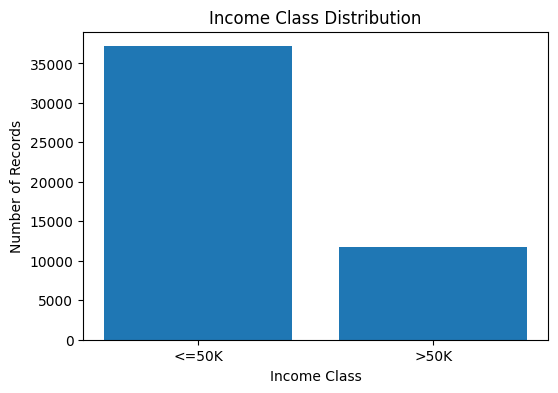

In [2]:
# ============================================================
# 2. 觀察目標欄位與缺漏標記
# ============================================================

# Adult 資料集中，有些缺漏值不是 NaN，而是用 ? 表示
# 因此先把 ? 轉成真正的 NaN，後面比較容易處理
adult = adult_data.copy()
adult = adult.replace("?", np.nan)

print("每個欄位的缺漏值數量：")
missing_count = adult.isna().sum().sort_values(ascending=False)
display(missing_count.head(10))

# 將 income 轉成二元分類目標：
# income_binary = 1 代表收入 >50K
# income_binary = 0 代表收入 <=50K
adult["income_binary"] = (adult["income"] == ">50K").astype(int)

income_count = adult["income_binary"].value_counts().sort_index()

print("收入類別筆數：")
print("<=50K：", income_count.loc[0])
print(">50K ：", income_count.loc[1])

# 視覺化收入類別比例
plt.figure(figsize=(6, 4))
plt.bar(["<=50K", ">50K"], [income_count.loc[0], income_count.loc[1]])
plt.title("Income Class Distribution")
plt.xlabel("Income Class")
plt.ylabel("Number of Records")
plt.show()

## 資料前處理設計

這裡選擇一些容易理解的欄位作為特徵。`fnlwgt` 在 Adult 資料集中比較像抽樣權重，對初學者來說較不直觀，因此本教學範例先不使用。

本範例會做三件事：

1. 類別欄位的缺漏值用該欄位最常出現的類別補上。
2. 類別欄位使用 `pd.get_dummies()` 轉成數值欄位。
3. 數值欄位使用 `StandardScaler` 標準化。

因為 `LogisticRegression` 會根據特徵數值大小估計模型係數，數值欄位經過標準化後，模型訓練通常會比較穩定。


In [3]:
# ============================================================
# 3. 選擇特徵、處理缺漏值、類別編碼
# ============================================================

# 數值型特徵
numeric_features = [
    "age",
    "educational-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

# 類別型特徵
categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "gender",
    "native-country"
]

# 合併所有要使用的特徵欄位
feature_columns = numeric_features + categorical_features

prepared_data = adult.copy()

# 將類別欄位的缺漏值補成該欄位最常出現的值
# 例如 workclass 缺漏時，可能會補成 Private
for column_name in categorical_features:
    most_common_value = prepared_data[column_name].mode()[0]
    prepared_data[column_name] = prepared_data[column_name].fillna(most_common_value)

# X 是模型輸入特徵，y 是模型要預測的答案
X = prepared_data[feature_columns].copy()
y = prepared_data["income_binary"].copy()

# LogisticRegression 只能處理數值資料
# 因此使用 pd.get_dummies() 將類別欄位轉成 0/1 欄位
X_encoded = pd.get_dummies(X, drop_first=True)

print("編碼後的特徵數量：")
print(X_encoded.shape[1])

print("\n編碼後的前 5 筆資料：")
display(X_encoded.head())

編碼後的特徵數量：
96

編碼後的前 5 筆資料：


,age,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Never-worked,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,7,0,0,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,18,10,0,0,30,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


In [4]:
# ============================================================
# 4. 切分訓練集與測試集，並標準化數值特徵
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.25,
    random_state=0,
    stratify=y
)

# 複製一份資料，避免直接修改原始的 X_train 與 X_test
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 只標準化原本的數值型欄位
# 注意：scaler 只能用訓練集 fit，再用同一個 scaler 轉換測試集
# 這樣可以避免把測試集資訊提前洩漏給模型
scaler = StandardScaler()
X_train_scaled[numeric_features] = scaler.fit_transform(X_train_scaled[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test_scaled[numeric_features])

print("訓練集筆數：", X_train_scaled.shape[0])
print("測試集筆數：", X_test_scaled.shape[0])

print("標準化後的數值欄位前 5 筆：")
display(X_train_scaled[numeric_features].head())

訓練集筆數： 36631
測試集筆數： 12211
標準化後的數值欄位前 5 筆：


,age,educational-num,capital-gain,capital-loss,hours-per-week
41661,2.731159,-0.418429,-0.145199,-0.218179,-2.207523
18686,-0.336752,0.359773,-0.145199,-0.218179,-0.032646
17188,-1.067207,1.137976,-0.145199,-0.218179,-2.046421
16286,-0.117615,1.527077,-0.145199,-0.218179,-0.032646
22974,0.247612,1.137976,-0.145199,-0.218179,3.994903


## 建立模型與評估

本範例使用 `LogisticRegression` 作為代表性的分類模型。它是分類問題中常見的基準模型，適合用來教學生理解「用特徵預測類別」的基本流程。

評估指標使用 `F1-score`。Adult Income 資料的 `<=50K` 與 `>50K` 類別比例不是完全平均，如果只看 accuracy，可能會忽略少數類別的預測效果。F1-score 會同時考慮 precision 與 recall，因此適合作為這個二元分類範例的代表性指標。


Logistic Regression F1-score： 0.6562
混淆矩陣表格：


,Predicted <=50K,Predicted >50K
True <=50K,8656,633
True >50K,1186,1736


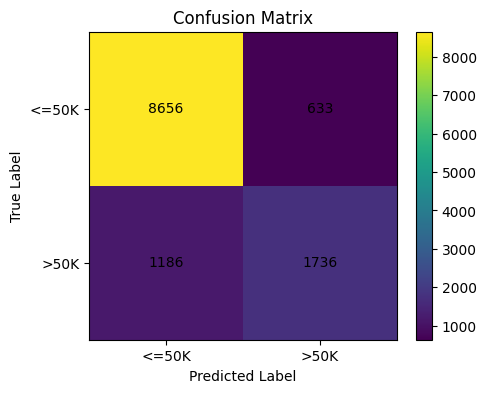

In [5]:
# ============================================================
# 5. 訓練 Logistic Regression，使用 F1-score 評估，並畫出混淆矩陣
# ============================================================

logistic_model = LogisticRegression(max_iter=1000, C=1.0, random_state=0)
logistic_model.fit(X_train_scaled, y_train)

# 使用測試集進行預測
predicted_income = logistic_model.predict(X_test_scaled)

# F1-score：同時考慮 precision 與 recall
f1 = f1_score(y_test, predicted_income)
print("Logistic Regression F1-score：", round(f1, 4))

# 混淆矩陣可以觀察模型預測對與錯的位置
confusion_result = confusion_matrix(y_test, predicted_income)
confusion_table = pd.DataFrame(
    confusion_result,
    index=["True <=50K", "True >50K"],
    columns=["Predicted <=50K", "Predicted >50K"]
)

print("混淆矩陣表格：")
display(confusion_table)

# 使用 matplotlib 視覺化混淆矩陣
plt.figure(figsize=(5, 4))
plt.imshow(confusion_result)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0, 1], ["<=50K", ">50K"])
plt.yticks([0, 1], ["<=50K", ">50K"])
plt.colorbar()

row_index = 0
while row_index < confusion_result.shape[0]:
    col_index = 0
    while col_index < confusion_result.shape[1]:
        plt.text(
            col_index,
            row_index,
            confusion_result[row_index, col_index],
            ha="center",
            va="center"
        )
        col_index = col_index + 1
    row_index = row_index + 1

plt.show()